## Step 1 — Setup

All required libraries are imported here. Random seeds are fixed to ensure
results are reproducible — running the notebook twice produces the same output.

In [1]:
# Install / upgrade packages if needed
# !pip install tensorflow numpy matplotlib seaborn scikit-learn --quiet

import os
import random
import warnings

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

# ── Class names ──────────────────────────────────────────────────────────────
CLASS_NAMES = [
    'T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle Boot'
]

# ── Output directories ───────────────────────────────────────────────────────
os.makedirs('../outputs', exist_ok=True)
os.makedirs('../models',  exist_ok=True)

print('Setup complete!')

TensorFlow version : 2.21.0
NumPy version      : 2.2.6
GPU available      : False
Setup complete!


## Step 2 — Load & Explore the Data

Fashion-MNIST contains **70,000 grayscale images** across 10 clothing categories.
The dataset is built into Keras — no manual download required.
We explore shapes, class balance, and visual appearance before any preprocessing.

In [2]:
# ── Load Fashion-MNIST ───────────────────────────────────────────────────────
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = \
    keras.datasets.fashion_mnist.load_data()

# ── Save to data/ ──────────────────────────────────────────────
os.makedirs('../data', exist_ok=True)
np.savez_compressed('../data/train.npz', X=X_train_raw, y=y_train_raw)
np.savez_compressed('../data/test.npz',  X=X_test_raw,  y=y_test_raw)
print('Dataset saved to data/')

print('Dataset loaded successfully!')
print('=' * 44)
print(f'Training images   : {X_train_raw.shape}')
print(f'Training labels   : {y_train_raw.shape}')
print(f'Test images       : {X_test_raw.shape}')
print(f'Test labels       : {y_test_raw.shape}')
print(f'Pixel range       : [{X_train_raw.min()}, {X_train_raw.max()}]')
print(f'Data type         : {X_train_raw.dtype}')
print(f'Number of classes : {len(CLASS_NAMES)}')

Dataset saved to data/
Dataset loaded successfully!
Training images   : (60000, 28, 28)
Training labels   : (60000,)
Test images       : (10000, 28, 28)
Test labels       : (10000,)
Pixel range       : [0, 255]
Data type         : uint8
Number of classes : 10


In [3]:
# ── Inspect one sample ───────────────────────────────────────────────────────
idx = 0
print(f'Sample index   : {idx}')
print(f'Label (number) : {y_train_raw[idx]}')
print(f'Label (name)   : {CLASS_NAMES[y_train_raw[idx]]}')
print(f'Image shape    : {X_train_raw[idx].shape}')
print(f'Min pixel      : {X_train_raw[idx].min()}')
print(f'Max pixel      : {X_train_raw[idx].max()}')
print(f'Mean pixel     : {X_train_raw[idx].mean():.2f}')
print()
print('Top-left 6x6 pixel values (raw):')
print(X_train_raw[idx][:6, :6])

Sample index   : 0
Label (number) : 9
Label (name)   : Ankle Boot
Image shape    : (28, 28)
Min pixel      : 0
Max pixel      : 255
Mean pixel     : 97.25

Top-left 6x6 pixel values (raw):
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


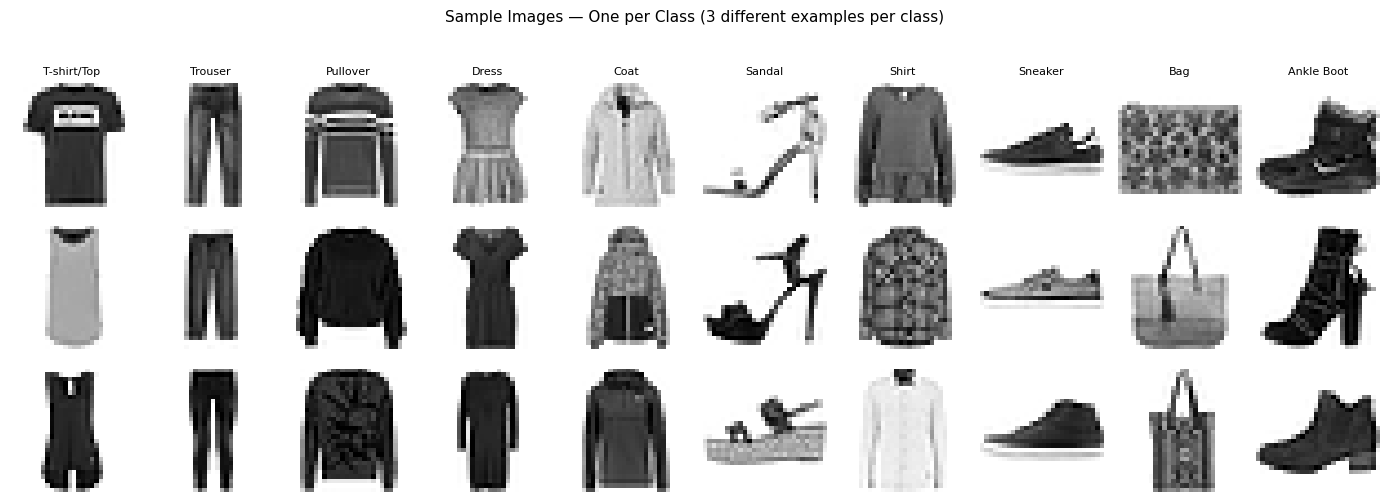

Saved: outputs/sample_images.png


In [4]:
# ── Visualise sample images — 3 rows x 10 classes ───────────────────────────
fig, axes = plt.subplots(3, 10, figsize=(14, 5))
fig.suptitle('Sample Images — One per Class (3 different examples per class)',
             fontsize=11, y=1.02)

for row in range(3):
    for col in range(10):
        sample_idx = np.where(y_train_raw == col)[0][row]
        axes[row, col].imshow(X_train_raw[sample_idx], cmap='gray_r')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[col], fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/sample_images.png')

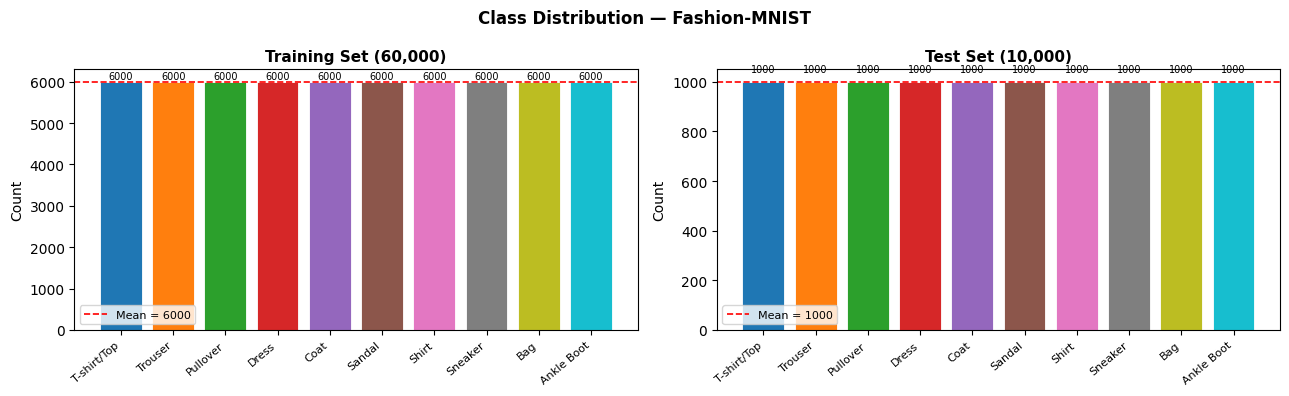

Dataset is perfectly balanced — 6,000 train / 1,000 test per class.
Saved: outputs/class_distribution.png


In [5]:
# ── Class distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, labels, title in zip(
    axes,
    [y_train_raw, y_test_raw],
    ['Training Set (60,000)', 'Test Set (10,000)']
):
    counts = np.bincount(labels)
    bars   = ax.bar(CLASS_NAMES, counts,
                    color=plt.cm.tab10.colors, edgecolor='white', linewidth=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=8)
    ax.axhline(y=counts.mean(), color='red', linestyle='--',
               linewidth=1.2, label=f'Mean = {counts.mean():.0f}')
    ax.legend(fontsize=8)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 30,
                str(count), ha='center', va='bottom', fontsize=7)

plt.suptitle('Class Distribution — Fashion-MNIST', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Dataset is perfectly balanced — 6,000 train / 1,000 test per class.')
print('Saved: outputs/class_distribution.png')

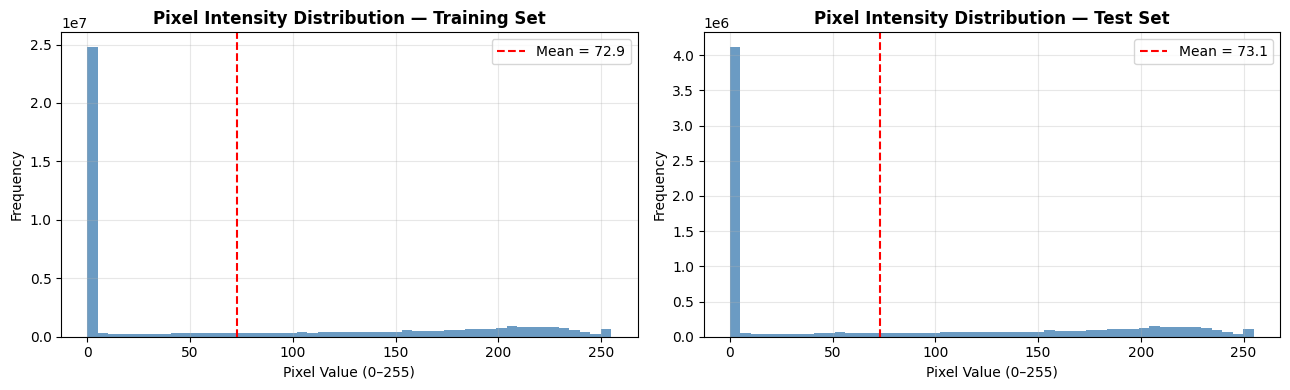

Saved: outputs/eda_pixel_distribution.png


In [8]:
# ── Pixel intensity distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, data, title in zip(
    axes,
    [X_train_raw.flatten(), X_test_raw.flatten()],
    ['Training Set', 'Test Set']
):
    ax.hist(data, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(f'Pixel Intensity Distribution — {title}', fontweight='bold')
    ax.set_xlabel('Pixel Value (0–255)')
    ax.set_ylabel('Frequency')
    ax.axvline(data.mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mean = {data.mean():.1f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/eda_pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/eda_pixel_distribution.png')

## Step 3 — Preprocessing

Before feeding images into LeNet-5 we perform three steps:
1. **Normalize** pixel values from `[0, 255]` to `[0.0, 1.0]` for stable gradient updates
2. **Reshape** images from `(28, 28)` to `(28, 28, 1)` to add the channel dimension required by `Conv2D`
3. **One-hot encode** labels for use with Categorical Crossentropy loss

We also **shuffle** the training data before splitting so the validation set is representative of all classes.